# Preparación del Entorno de Trabajo en Python

Antes de abordar la visualización y resolución del problema de optimización, es necesario preparar el entorno de trabajo en Python. Esto implica importar las bibliotecas necesarias que permitirán tanto la formulación y resolución del problema de optimización como su visualización gráfica. Las bibliotecas utilizadas son NumPy, Matplotlib y CVXPY.

### Importación de Bibliotecas:

1. **NumPy**:
   - Importamos `numpy` con el alias `np`.
   - NumPy es una biblioteca fundamental para la computación científica en Python, proporcionando soporte para arrays y matrices, junto con una colección de funciones matemáticas para operar en estos arrays.

2. **Matplotlib**:
   - Importamos `matplotlib.pyplot` con el alias `plt`.
   - Matplotlib es una biblioteca de gráficos 2D en Python que produce figuras de calidad en una variedad de formatos impresos y entornos interactivos.

3. **CVXPY**:
   - Importamos `cvxpy` con el alias `cp`.
   - CVXPY es una biblioteca de Python para la optimización convexa que facilita la formulación y resolución de problemas matemáticos de optimización.

4. **Configuración de Matplotlib**:
   - Utilizamos `%matplotlib inline` para configurar el entorno de Jupyter Notebook, asegurando que los gráficos de Matplotlib se muestren directamente en el notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cvxpy as cp

<hr style="height: 2px; background-color: black; border: none;">

# Ejemplo 1: Función Convexa

---

## Optimización con Restricciones usando CVXPY

En este ejemplo, utilizamos la biblioteca CVXPY para resolver un problema de optimización con restricciones. El objetivo es maximizar una función objetivo sujeta a un conjunto de restricciones lineales.

### Definición del Problema

El problema se define con las siguientes características:

- **Variables de Decisión**: 
  - `x1` y `x2`, que son las variables sobre las cuales optimizaremos.

- **Restricciones**:
  - La suma de 2 veces `x1` más `x2` debe ser menor o igual a 3.
  - Tanto `x1` como `x2` deben ser mayores o iguales a 0.

- **Función Objetivo**:
  - Maximizar el logaritmo natural de (`x1` + 1) más `x2`.

La función objetivo y las restricciones se definen de tal manera que el problema cae dentro del marco de la programación convexa, permitiendo su resolución eficiente.

### Implementación en CVXPY

La implementación en CVXPY se realiza en varios pasos:

1. Definir las variables `x1` y `x2` como variables de optimización.
2. Establecer las restricciones del problema.
3. Definir la función objetivo que deseamos maximizar.
4. Crear y resolver el problema de optimización.

In [3]:
x1 = cp.Variable()
x2 = cp.Variable()

constraints = [2*x1 + x2 <= 3, x1>=0, x2 >=0]

obj = cp.Maximize(cp.log(x1+1)+x2)

prob = cp.Problem(obj, constraints)

------
## Análisis de Convexidad en Optimización con CVXPY

En este ejemplo, se utiliza CVXPY, una poderosa herramienta para la optimización convexa, para analizar la convexidad de una función específica dentro de un problema de optimización. El análisis de convexidad es fundamental en la optimización, ya que determina si un problema puede ser resuelto de manera eficiente.

### Expresión a Analizar

La expresión que se analizará en este caso es una combinación de una función logarítmica y una variable lineal. El propósito es verificar si esta expresión es convexa. En la optimización convexa, una función es convexa si y solo si cumple con ciertas propiedades matemáticas que permiten encontrar soluciones globales óptimas.

La expresión específica a verificar es `-(cp.log(x1+1) + x2)`, donde `x1` y `x2` son variables de decisión. Esta expresión incluye:

- La función logarítmica `log(x1+1)`, que es conocida por sus propiedades de convexidad.
- La adición de `x2`, una variable lineal.

### Uso de CVXPY para la Verificación

CVXPY proporciona herramientas para definir problemas de optimización y verificar propiedades como la convexidad de las expresiones. Utilizando el método `.is_convex()`, podemos determinar si la expresión dada es convexa. Este análisis es crucial para asegurar que el problema de optimización puede ser resuelto eficientemente.

In [4]:
(-(cp.log(x1+1)+x2)).is_convex()

True

---
## Resolución y Resultados del Problema de Optimización

Una vez definido el problema de optimización con sus variables, restricciones y función objetivo en CVXPY, el siguiente paso es resolver el problema y analizar los resultados. Esto se logra mediante el método `.solve()` y accediendo a los valores óptimos de las variables de decisión.

### Código de Resolución y Análisis de Resultados

El código proporcionado realiza las siguientes operaciones:

1. **Resolución del Problema**:
   - Utiliza `prob.solve()` para resolver el problema de optimización. Este método aplica un algoritmo de optimización para encontrar los valores de las variables que maximizan o minimizan la función objetivo, sujeto a las restricciones definidas.

2. **Obtención de Resultados**:
   - `prob.solve():.2f` devuelve el valor óptimo de la función objetivo, redondeado a dos decimales.
   - `x1.value` y `x2.value` obtienen los valores de las variables `x1` y `x2` en el punto óptimo, respectivamente.

3. **Impresión de Resultados**:
   - El código imprime el valor óptimo de la función objetivo y las coordenadas del punto óptimo donde se alcanza este valor.

In [6]:
print(f'El valor óptimo es: {prob.solve():.2f}')
print(f'Se alcanza en el punto: ({x1.value:.2f}, {x2.value:.2f})')

El valor óptimo es: 3.00
Se alcanza en el punto: (0.00, 3.00)


---
## Visualización Gráfica del Problema de Optimización

Después de resolver un problema de optimización utilizando CVXPY, es útil visualizar la región factible y cómo la función objetivo varía dentro de esta región. El siguiente código Python utiliza la biblioteca Matplotlib para crear un gráfico que muestra estas características.

### Pasos del Código:

1. **Definición de Variables de Solución**:
   - `sol_x1` y `sol_x2` capturan los valores óptimos de las variables de decisión `x1` y `x2`.

2. **Creación de un Grid de Puntos**:
   - Se generan arrays `x1_vals` y `x2_vals` con valores linealmente espaciados.
   - Se crea una malla de puntos (`x1_grid`, `x2_grid`) utilizando estos arrays.

3. **Evaluación de Restricciones**:
   - Se evalúan las restricciones del problema en cada punto de la malla para identificar la región factible.

4. **Cálculo de la Función Objetivo**:
   - Se calcula el valor de la función objetivo en cada punto de la malla.

5. **Visualización con Matplotlib**:
   - Se utiliza `imshow` para representar la región factible.
   - Se dibujan las líneas de contorno de la función objetivo.
   - Se marca la solución óptima en el gráfico.
   - Se configuran las etiquetas y el título del gráfico, junto con una barra de colores que representa los valores de la función objetivo.

6. **Mostrar el Gráfico**:
   - Se utiliza `plt.show()` para mostrar el gráfico resultante.

### Resultado Esperado:

El gráfico resultante proporciona una visualización clara de dónde se encuentra la región factible y cómo la función objetivo varía dentro de esta región. La solución óptima se destaca, permitiendo una comprensión visual del resultado de la optimización.


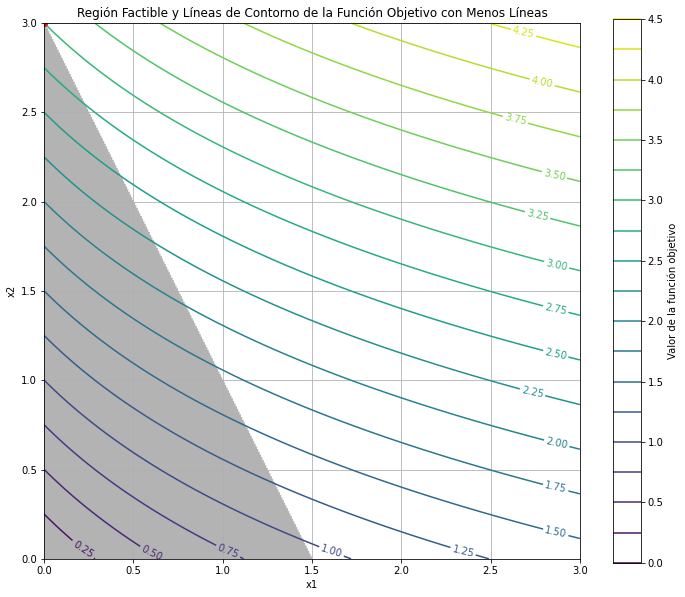

In [11]:
# Definición de las variables del problema de optimización.
sol_x1 = x1.value
sol_x2 = x2.value

# Crear un grid de puntos para evaluar las restricciones y la función objetivo.
x1_vals = np.linspace(0, 3, 400)
x2_vals = np.linspace(0, 3, 400)
x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)

# Evaluar las restricciones para determinar la región factible.
constraint1 = 2 * x1_grid + x2_grid <= 3
constraint2 = x1_grid >= 0
constraint3 = x2_grid >= 0

# Crear la función objetivo para las líneas de contorno.
objective = np.log(x1_grid + 1) + x2_grid

# Iniciar la figura de matplotlib con menos líneas de contorno.
plt.figure(figsize=(12, 10))

# Dibujar la región factible.
plt.imshow(((constraint1) & (constraint2) & (constraint3)).astype(int), 
           extent=(x1_grid.min(), x1_grid.max(), x2_grid.min(), x2_grid.max()), 
           origin="lower", cmap="Greys", alpha=0.3)

# Dibujar menos líneas de contorno de la función objetivo.
contours = plt.contour(x1_grid, x2_grid, objective, levels=20, cmap="viridis") # reducido a 20 niveles
plt.clabel(contours, inline=1, fontsize=10)

# Dibujar la solución óptima.
plt.plot(sol_x1, sol_x2, 'ro') # punto de solución óptima x1=0, x2=3

# Configurar las etiquetas y título del gráfico.
plt.title('Región Factible y Líneas de Contorno de la Función Objetivo con Menos Líneas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(contours, label='Valor de la función objetivo')
plt.grid(True)
plt.show()

La gráfica muestra la región factible en gris, las líneas de contorno de la función objetivo en colores variados y la solución óptima con un punto rojo. 

<hr style="height: 2px; background-color: black; border: none;">

# Ejemplo 2: Función No Convexa

---

## Formulación del Problema de Optimización con CVXPY

El siguiente segmento de código utiliza CVXPY para formular un problema de optimización. CVXPY es una biblioteca de Python que facilita la definición y resolución de problemas de optimización convexa. En este ejemplo, definimos un problema con dos variables de decisión, restricciones específicas y una función objetivo.

### Definición de Variables de Decisión:

1. **Variables `x1` y `x2`**:
   - Se crean dos variables de decisión, `x1` y `x2`, utilizando `cp.Variable()`.
   - Estas variables representan las cantidades que queremos optimizar.

### Establecimiento de Restricciones:

Se definen las siguientes restricciones para el problema:

1. **Restricción Cuadrática**: La suma de `x1` al cuadrado y `x2` debe ser menor o igual a 3.
2. **Restricciones de No Negatividad**: Tanto `x1` como `x2` deben ser mayores o iguales a 0.

### Definición de la Función Objetivo:

- **Función Objetivo**: Maximizar el producto de `x1` y `x2`.
- Este tipo de función objetivo puede ser común en problemas de optimización donde se busca maximizar el rendimiento o la eficiencia de dos variables dependientes.

### Creación del Problema de Optimización:

- Se crea un objeto de problema `prob` utilizando `cp.Problem()`, pasando la función objetivo y las restricciones.
- Este objeto será utilizado posteriormente para resolver el problema.


In [21]:
x1 = cp.Variable()
x2 = cp.Variable()

constraints = [x1**2 + x2 <= 3, x1>=0, x2 >=0 ]

obj = cp.Maximize(x1*x2)

prob = cp.Problem(obj, constraints)

---

## Verificación de la Convexidad de una Expresión en CVXPY

En optimización convexa, es crucial determinar si una función o expresión es convexa, ya que esto afecta tanto la solubilidad del problema como la naturaleza de las soluciones que se pueden encontrar. El código proporcionado utiliza CVXPY para verificar la convexidad de una expresión específica.

### Expresión a Verificar:

- La expresión en cuestión es `-(x1*x2)`, donde `x1` y `x2` son variables de decisión previamente definidas.
- Esta expresión es el negativo del producto de `x1` y `x2`.

### Uso de CVXPY para la Verificación de Convexidad:

- CVXPY proporciona una forma sencilla y eficiente de verificar la convexidad de expresiones matemáticas.
- El método `.is_convex()` devuelve `True` si la expresión es convexa y `False` en caso contrario.

In [13]:
(-(x1*x2)).is_convex()

False

## Análisis del Resultado de la Verificación de Convexidad

Al ejecutar el código `(-(x1*x2)).is_convex()` en CVXPY, hemos obtenido un resultado `False`. Este resultado tiene implicaciones significativas en el contexto de la optimización convexa.

### Significado del Resultado `False`

El resultado `False` indica que la expresión `-(x1*x2)` **no es convexa**. En la optimización convexa, la convexidad de una función es un atributo clave que afecta las propiedades del problema de optimización:

- **Convexidad**: Una función es convexa si, para cualquier par de puntos en su dominio, la línea que conecta estos puntos está siempre por encima o sobre el gráfico de la función.
- **No Convexidad de `-(x1*x2)`**: La expresión dada es el negativo del producto de dos variables. Matemáticamente, esta forma no satisface la definición de una función convexa.

### Implicaciones para Problemas de Optimización

- **Desafíos en la Optimización**: La no convexidad implica que el problema asociado puede tener múltiples óptimos locales. En tales casos, encontrar el óptimo global no está garantizado utilizando métodos de optimización estándar.
- **Necesidad de Métodos Alternativos**: Puede ser necesario emplear estrategias de optimización más sofisticadas o heurísticas para abordar este tipo de problemas, especialmente cuando se busca una solución global óptima.

### Conclusión

El resultado `False` obtenido de la verificación de convexidad resalta la importancia de analizar cuidadosamente la naturaleza de las funciones utilizadas en problemas de optimización. La elección de funciones convexas facilita la solución de problemas y asegura la existencia de soluciones óptimas globales bajo ciertas condiciones.


---

## Resolución del Problema de Optimización y Extracción de Resultados

Una vez formulado el problema de optimización en CVXPY, el siguiente paso es resolverlo y obtener los resultados. El código proporcionado realiza esta tarea y luego imprime el valor óptimo alcanzado y las coordenadas del punto en el que se logra este valor óptimo.

### Ejecución del Solver

- El método `solve()` de CVXPY se utiliza para resolver el problema de optimización.
- `prob.solve()` calcula el valor óptimo de la función objetivo dadas las restricciones definidas.
- El valor devuelto es el máximo o mínimo de la función objetivo, dependiendo de si se trata de un problema de maximización o minimización.

### Impresión de Resultados

- Una vez resuelto el problema, se accede a los valores de las variables de decisión (`x1` y `x2`) a través de `x1.value` y `x2.value`.
- Estos valores representan el punto (en términos de las variables de decisión) donde se alcanza el valor óptimo.
- Se imprimen tanto el valor óptimo como las coordenadas del punto óptimo.

In [14]:
print(f'El valor óptimo es: {prob.solve():.2f}')
print(f'Se alcanza en el punto: ({x1.value:.2f}, {x2.value:.2f})')

DCPError: Problem does not follow DCP rules. Specifically:
The objective is not DCP. Its following subexpressions are not:
var94 @ var95

## Comprensión del Error `DCPError` en CVXPY

Al intentar resolver un problema de optimización utilizando CVXPY, podemos encontrarnos con un `DCPError`. Este error indica que el problema no cumple con las reglas de Programación Convexa Disciplinada (DCP). Estas reglas son fundamentales para asegurar la convexidad del problema y la eficacia de los algoritmos de optimización.

### ¿Qué es DCP?

- **Disciplined Convex Programming (DCP)** es un sistema de reglas que facilita la construcción de problemas de optimización convexos.
- CVXPY utiliza DCP para verificar automáticamente la convexidad de un problema.

### Causas Comunes del `DCPError`:

1. **Función Objetivo No Convexa**: Si la función objetivo no es convexa (en problemas de minimización) o cóncava (en problemas de maximización), CVXPY arrojará un `DCPError`.
2. **Restricciones No Convexas**: De manera similar, todas las restricciones deben ser convexas. Esto significa que el conjunto definido por las restricciones debe ser un conjunto convexo.

### Análisis del Problema Actual:

- En el código proporcionado, el objetivo es maximizar `x1 * x2`. Sin embargo, el producto de dos variables no es una operación convexa, lo que resulta en un incumplimiento de las reglas DCP.
- Esto es especialmente cierto si no hay restricciones adicionales que hagan que el producto de `x1` y `x2` sea una operación convexa o cóncava.

### Soluciones Posibles:

1. **Reformular el Problema**: Revisa la formulación de tu problema. Considera si el objetivo puede ser modificado para cumplir con las reglas DCP.
2. **Verificación de Restricciones**: Asegúrate de que todas las restricciones sean convexas. A veces, una pequeña modificación puede hacer que el problema cumpla con las reglas DCP.
3. **Consultar la Documentación de CVXPY**: Revisar ejemplos similares o la documentación de CVXPY puede proporcionar ideas sobre cómo reformular el problema de manera que cumpla con las reglas DCP.

### Conclusión

El `DCPError` es una herramienta útil para identificar problemas en la formulación de problemas de optimización en CVXPY. Asegurarse de que tanto la función objetivo como las restricciones cumplan con las reglas DCP es crucial para la resolución exitosa del problema.


---

## Visualización de la Función en 3D con Matplotlib

El siguiente fragmento de código utiliza las bibliotecas `numpy` y `matplotlib` para visualizar la función de dos variables $f(x, y) = x \cdot y$, en un gráfico 3D.

### Creación de la cuadrícula de valores:

1. **Variables `x` e `y`**:
   - Se crean dos matrices de valores, `x` e `y`, utilizando `np.linspace(-5, 5, 100)`. Esto genera 100 puntos igualmente espaciados entre -5 y 5 para cada variable.
   - Luego, se utiliza `np.meshgrid(x, y)` para crear una cuadrícula de coordenadas a partir de los valores de `x` e `y`.

### Cálculo de los valores de la función:

2. **Variable `z`**:
   - Se calculan los valores de la función $f(x, y) = x \cdot y$ para cada par de puntos `(x, y)` en la cuadrícula.

### Creación del gráfico 3D:

3. **Figura y ejes**:
   - Se crea una figura utilizando `plt.figure(figsize=(10, 10))`. Esto crea una figura de 10x10 pulgadas.
   - Luego, se añade un subplot 3D a la figura con `fig.add_subplot(111, projection='3d')`.

4. **Superficie 3D**:
   - Se dibuja la superficie 3D utilizando `ax.plot_surface(x, y, z, cmap='viridis')`. Esto crea una superficie 3D donde la altura de la superficie en cada punto `(x, y)` es igual al valor de `z` en ese punto.

Finalmente, se muestra la figura con `plt.show()`. Esto genera el gráfico 3D de la función.

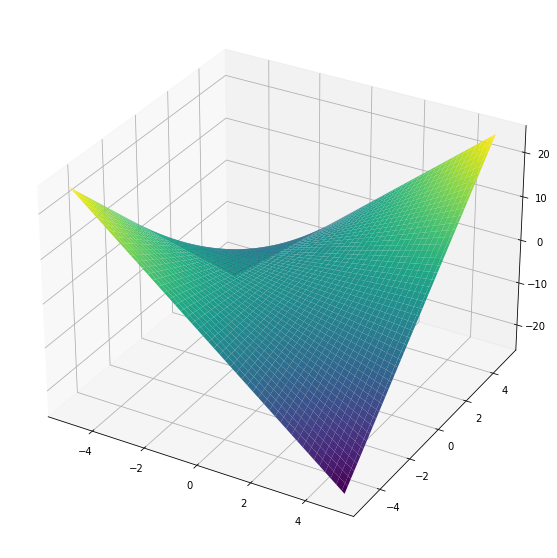

In [33]:
# Importar las bibliotecas necesarias
from mpl_toolkits.mplot3d import Axes3D

# Crear una cuadrícula de valores para x e y
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)

# Calcular los valores de z como el producto de x e y
z = x * y

# Crear una nueva figura con un tamaño específico
fig = plt.figure(figsize=(10, 10))

# Añadir un subplot 3D a la figura
ax = fig.add_subplot(111, projection='3d')

# Dibujar la superficie en el subplot 3D
ax.plot_surface(x, y, z, cmap='viridis')

# Mostrar la figura
plt.show()
